In [1]:
import pandas as pd
import numpy as np

In [2]:
merged = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
merged

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.188543,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.566125,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.188543,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489


In [3]:
merged

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.188543,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.566125,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.188543,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489


In [4]:
## play here

In [5]:
import pandas as pd

# Step 1: Load your merged loop dataframe
#merged = pd.read_csv("your_merged_loop_file.csv")  # update with your actual file path

# Step 2: Construct a unique key for each loop
merged['loop_key'] = merged[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']] \
    .astype(str).agg('_'.join, axis=1)

# Step 3: Define a function to load BEDPE loop keys
def load_keys(file):
    df = pd.read_csv(file, sep="\t", header=None)
    return set(df.iloc[:, :6].astype(str).agg('_'.join, axis=1))

# Step 4: Load loop keys for each chromatin mark (union of ctrl + rbp1)
ctcf_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
            load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_rbp1.bedpe")

h3k27me3_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
                load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_rbp1.bedpe")

cohesin_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/cohesin_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
               load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/cohesin_associated_loops_eitheranchoroverlap_rbp1.bedpe")

# Step 5: Annotate each loop with Yes/No per mark
merged['CTCF'] = merged['loop_key'].apply(lambda x: 'Yes' if x in ctcf_keys else 'No')
merged['H3K27me3'] = merged['loop_key'].apply(lambda x: 'Yes' if x in h3k27me3_keys else 'No')
merged['Cohesin'] = merged['loop_key'].apply(lambda x: 'Yes' if x in cohesin_keys else 'No')

# Step 6 (optional): Drop the temporary loop_key
merged.drop(columns=['loop_key'], inplace=True)

merged

# Step 7 (optional): Save the annotated dataframe
#merged.to_csv("merged_with_chromatin_marks.csv", index=False)


,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,CTCF,H3K27me3,Cohesin
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.0494,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.0578,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,No
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.0102,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987,No,No,No
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987,No,No,No
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464,No,No,Yes
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489,No,No,No


In [6]:
mark_counts = {
    "CTCF": (merged["CTCF"] == "Yes").sum(),
    "H3K27me3": (merged["H3K27me3"] == "Yes").sum(),
    "Cohesin": (merged["Cohesin"] == "Yes").sum()
}
print(mark_counts)

{'CTCF': 5006, 'H3K27me3': 1699, 'Cohesin': 17321}


In [7]:
# dimension check 
merged.shape

(32277, 34)

In [8]:
merged

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,CTCF,H3K27me3,Cohesin
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.0494,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.0578,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,No
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.0102,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987,No,No,No
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987,No,No,No
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464,No,No,Yes
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489,No,No,No


---

In [9]:
X = merged[['ctrl_signal', "rbp1_signal", "comp_switch_A1", "comp_switch_A2", "loop_class", "CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "GC_mean", "GC_diff", "E1_anchor1_ctrl", "E1_anchor1_rbp1",	"E1_anchor2_ctrl", "E1_anchor2_rbp1","delta_E1_anchor1","delta_E1_anchor2"]]
X["log_distance"] = np.log1p(merged["distance"])

#X['CTCF'] = (X['CTCF'] == 'Yes').astype(int)
#X['H3K27me3'] = (X['H3K27me3'] == 'Yes').astype(int)
#X['Cohesin'] = (X['Cohesin'] == 'Yes').astype(int)

X = pd.get_dummies(X, columns=['comp_switch_A1', 'comp_switch_A2'], dummy_na=True)
X = X.fillna(0)


/tmp/ipykernel_1089930/2102473246.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["log_distance"] = np.log1p(merged["distance"])


In [10]:
#X['CTCF_H3K27me3'] = X['CTCF'] & X['H3K27me3']
#X['CTCF_Cohesin'] = X['CTCF'] & X['Cohesin']
#X['H3K27me3_Cohesin'] = X['H3K27me3'] & X['Cohesin']
#X['Hybrid_Loop'] = ((X['CTCF'] + X['H3K27me3'] + X['Cohesin']) > 1).astype(int)

In [11]:
y = merged["status"]  # This is your target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'gained' = 0, 'lost' = 1, 'shared' = 2 (example)


In [12]:
X["loop_class_encoded"] = X["loop_class"].map({
    "intra-TAD": 0,
    "inter-TAD": 1,
    "uncategorized": 2
})

In [13]:
X = X.drop(columns=["loop_class"])

In [14]:
X

,ctrl_signal,rbp1_signal,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,...,log_distance,comp_switch_A1_A_to_B,comp_switch_A1_B_to_A,comp_switch_A1_stable,comp_switch_A1_nan,comp_switch_A2_A_to_B,comp_switch_A2_B_to_A,comp_switch_A2_stable,comp_switch_A2_nan,loop_class_encoded
0,0.000000,0.000000,3.719732,1.930504,0.188543,0.024018,0.5773,0.0494,0.000000,0.000000,...,11.407576,False,False,False,True,False,False,False,True,2
1,0.000000,0.000000,62.158684,1.542050,0.566125,0.063427,0.6135,0.0578,0.000000,0.000000,...,12.100718,False,False,False,True,False,False,False,True,2
2,0.000000,0.000000,13.704273,4.520206,0.188543,0.044699,0.6525,0.0102,0.000000,0.000000,...,11.849405,False,False,False,True,False,False,False,True,2
3,0.000000,0.000000,1.076765,5.414830,0.188543,0.024769,0.6002,0.0948,0.000000,0.000000,...,11.736077,False,False,False,True,False,False,False,True,2
4,0.000000,0.000000,16.477770,1.377250,0.188543,0.042592,0.5949,0.0842,0.000000,0.000000,...,10.819798,False,False,False,True,False,False,False,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,0.006078,0.006342,0.000000,0.000000,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,...,12.751303,False,False,True,False,False,False,True,False,0
32273,0.007661,0.005159,0.522068,0.188342,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,...,12.644331,False,False,True,False,False,False,True,False,0
32274,0.001017,0.001021,0.261034,0.082400,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,...,12.971543,False,False,True,False,False,False,True,False,2
32275,0.004674,0.006621,0.293663,0.188342,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,...,12.345839,False,False,True,False,False,False,True,False,0


In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns


features = [
    'ctrl_signal', 'rbp1_signal', 'CTCF_signal', 'H3K27me3_signal',
    'H3K4me3_signal', 'rad21_signal', 'GC_mean', 'GC_diff',
    'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'log_distance'
]

X_dim_proj = X[features]
X_scaled = StandardScaler().fit_transform(X_dim_proj)

# t-SNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_scaled)

# UMAP
X_umap = UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


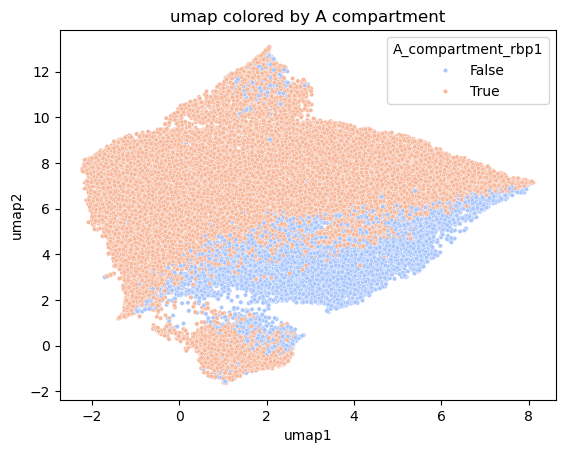

In [16]:
# Add results to df
X['tsne1'] = X_tsne[:, 0]
X['tsne2'] = X_tsne[:, 1]
X['umap1'] = X_umap[:, 0]
X['umap2'] = X_umap[:, 1]

# Optional: Add binary feature
X['A_compartment_rbp1'] = X['E1_anchor1_rbp1'] > 0

# Now you can plot safely
sns.scatterplot(data=X, x='umap1', y='umap2', hue='A_compartment_rbp1', palette='coolwarm', s=10)
plt.title("umap colored by A compartment")
plt.show()

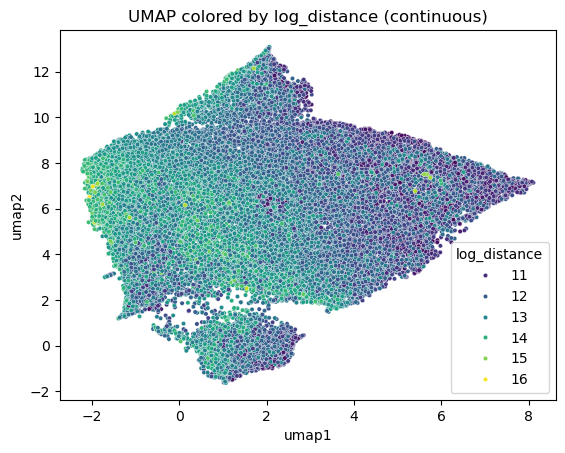

In [17]:
X['log_distance'] = pd.to_numeric(X['log_distance'], errors='coerce')

sns.scatterplot(data=X, x='umap1', y='umap2', hue='log_distance', palette='viridis', s=10)
plt.title("UMAP colored by log_distance (continuous)")
plt.show()


<Axes: xlabel='tsne1', ylabel='tsne2'>

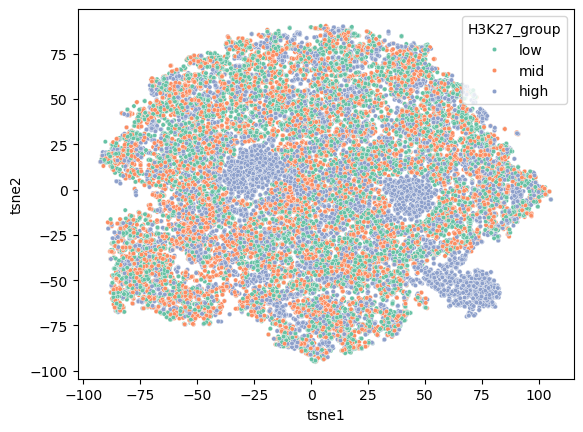

In [29]:
X['H3K27_group'] = pd.qcut(X['H3K27me3_signal'], q=3, labels=['low', 'mid', 'high'])
sns.scatterplot(x='tsne1', y='tsne2', hue='H3K27_group', data=X, palette='Set2', s=10)

<Axes: xlabel='umap1', ylabel='umap2'>

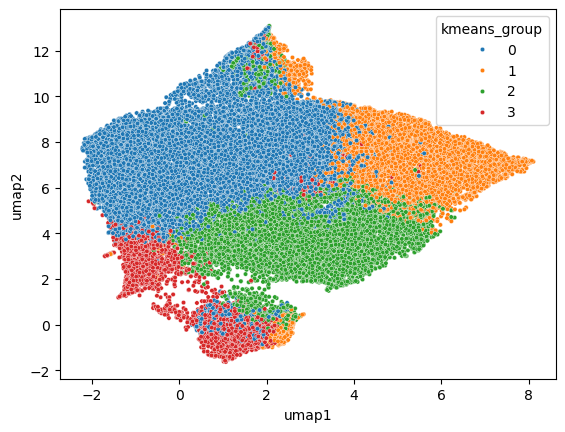

In [30]:
from sklearn.cluster import KMeans
X['kmeans_group'] = KMeans(n_clusters=4).fit_predict(X_scaled)

sns.scatterplot(x='umap1', y='umap2', hue='kmeans_group', data=X, palette='tab10', s=10)

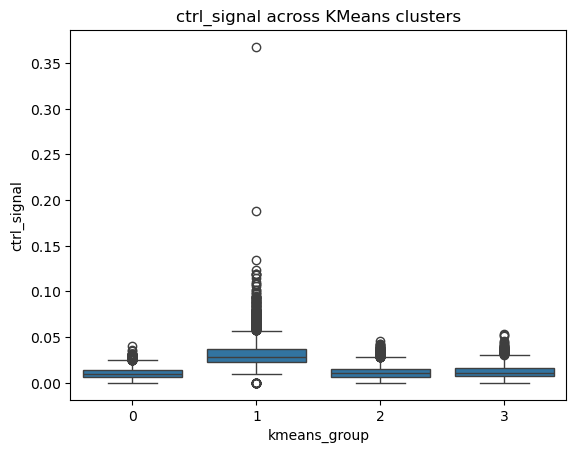

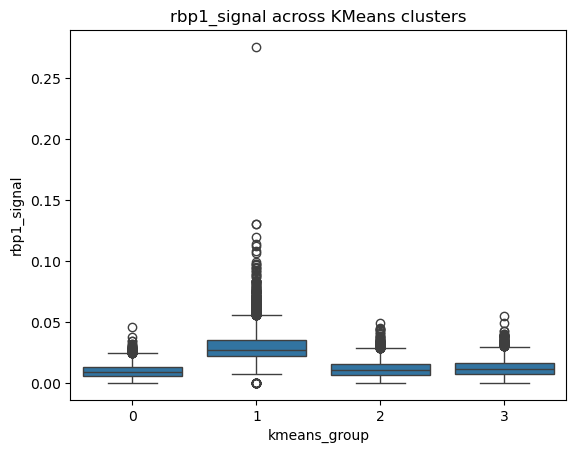

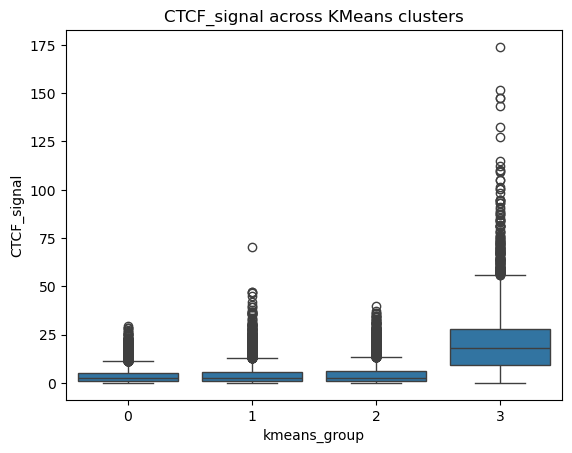

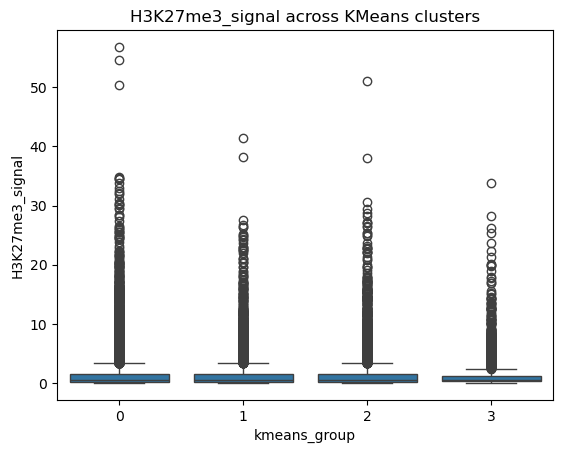

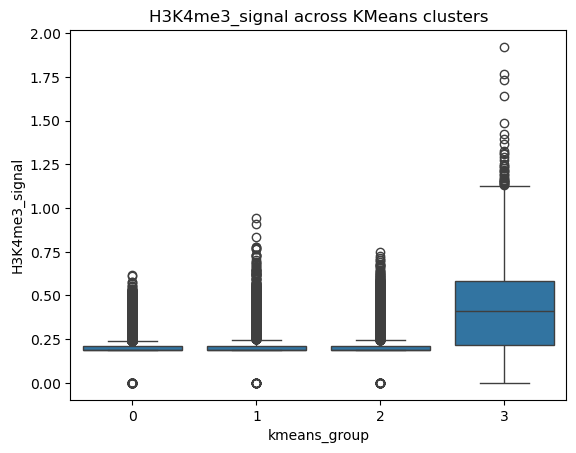

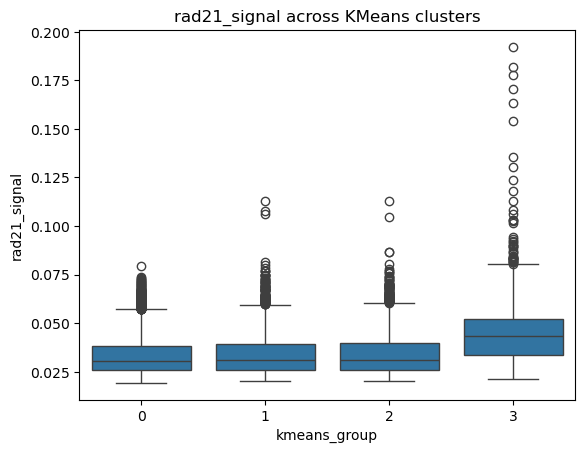

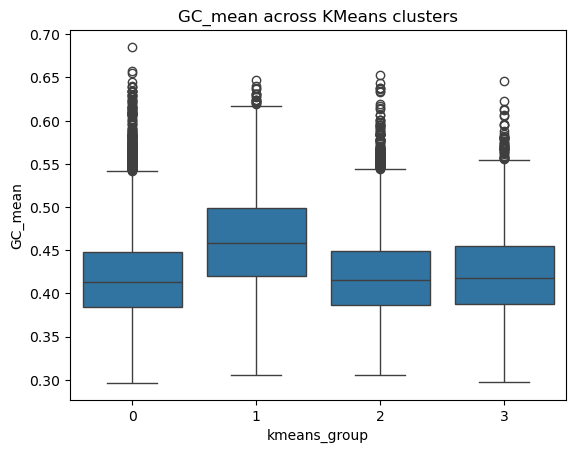

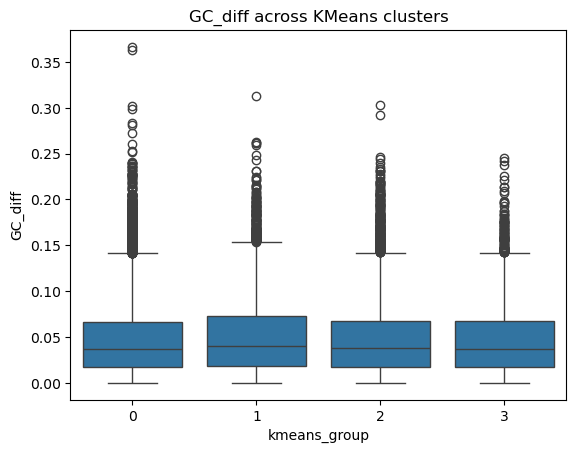

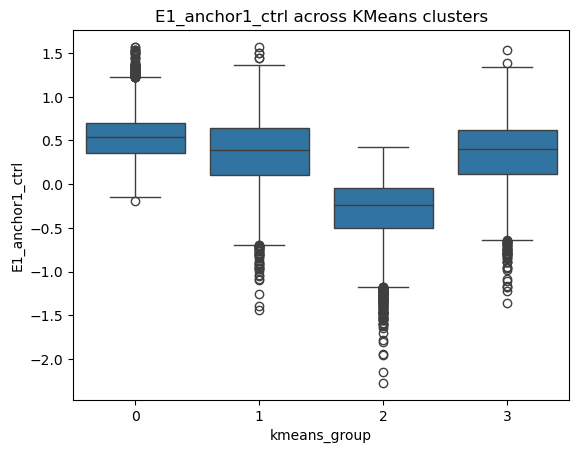

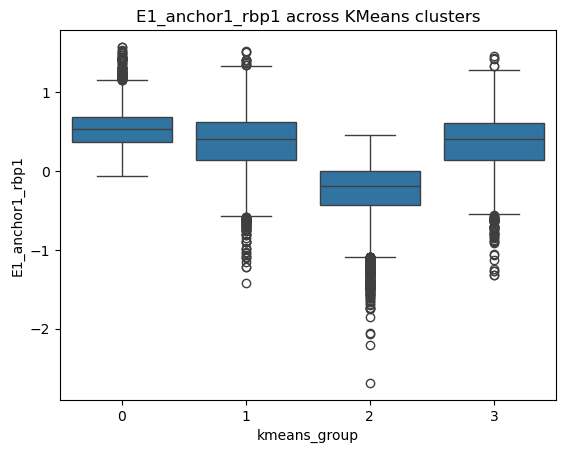

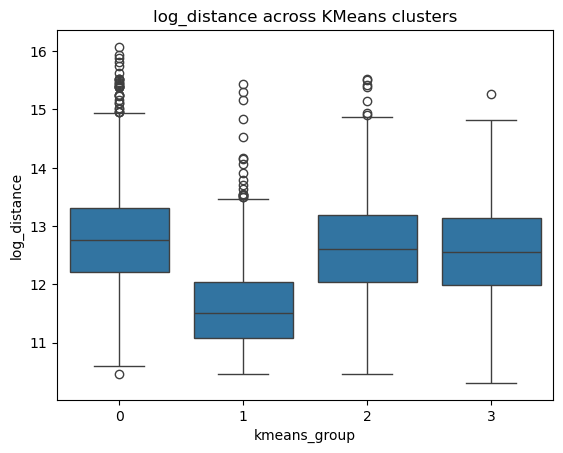

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots: feature vs. cluster
for feature in features:
    sns.boxplot(data=X, x='kmeans_group', y=feature)
    plt.title(f"{feature} across KMeans clusters")
    plt.show()


In [32]:
from sklearn.decomposition import NMF

# 1. Ensure non-negativity
X_nmf_input = X[features].clip(lower=0)

# 2. Fit NMF
nmf_model = NMF(n_components=3, random_state=42)
W = nmf_model.fit_transform(X_nmf_input)  # shape: (n_samples, 3)
H = nmf_model.components_                 # shape: (3, n_features)

# 3. Add components to DataFrame
X['nmf1'], X['nmf2'], X['nmf3'] = W[:, 0], W[:, 1], W[:, 2]


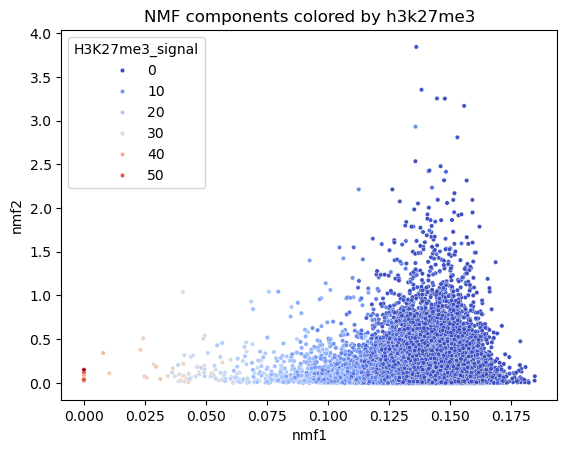

In [35]:
sns.scatterplot(x='nmf1', y='nmf2', hue='H3K27me3_signal', data=X, palette='coolwarm', s=10)
plt.title("NMF components colored by h3k27me3")
plt.show()


In [18]:
y_encoded

array([2, 2, 2, ..., 0, 0, 0])

### XGBoost

In [19]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Handle infinite values
print("Checking for infinite values...")
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Convert to float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Ensure target is integer
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Train XGBoost
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Evaluation
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Multi-class AUC (macro average, using One-vs-Rest)
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
print("Macro-average AUC (OvR):", roc_auc_score(y_test_binarized, y_proba, average="macro", multi_class="ovr"))

# Debug info
print("\nData Info:")
print("X_train shape:", X_train.shape)
print("NaNs in X_train:", np.isnan(X_train).sum())
print("Inf in X_train:", np.isinf(X_train).sum())
print("X_train min:", np.nanmin(X_train))
print("X_train max:", np.nanmax(X_train))

print("\ny_train info:")
print("Type:", type(y_train))
print("Dtype:", y_train.dtype)
print("Shape:", y_train.shape)
print("NaNs:", np.isnan(y_train).sum())


Checking for infinite values...
              precision    recall  f1-score   support

      gained       0.61      0.72      0.66      2607
        lost       0.65      0.61      0.63      2379
      shared       0.53      0.43      0.47      1470

    accuracy                           0.61      6456
   macro avg       0.60      0.58      0.59      6456
weighted avg       0.61      0.61      0.61      6456

Macro-average AUC (OvR): 0.7901456520654154

Data Info:
X_train shape: (25821, 29)
NaNs in X_train: 0
Inf in X_train: 0
X_train min: -95.12364
X_train max: 174.04437

y_train info:
Type: <class 'numpy.ndarray'>
Dtype: int64
Shape: (25821,)
NaNs: 0


In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# === 1. Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# === 2. Replace inf ===
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# === 3. Impute ===
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# === 4. Type convert ===
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# === 5. Apply multi-class SMOTE ===
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 6. Grid search ===
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',  # Use accuracy or macro F1, not AUC here
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)
model = grid.best_estimator_

# === 7. Predict ===
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# === 8. Evaluation ===
print("\nBest Parameters:", grid.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# === 9. Multi-class ROC AUC ===
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
print("Macro-average AUC (OvR):", roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'))

# === 10. Debug info ===
print("\nX_train shape:", X_train.shape)
print("NaNs:", np.isnan(X_train).sum(), "Infs:", np.isinf(X_train).sum())
print("Min:", np.nanmin(X_train), "Max:", np.nanmax(X_train))
print("y_train unique:", np.unique(y_train))


Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:13:03] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:13:04] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:13:05] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/us


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

Classification Report:
               precision    recall  f1-score   support

      gained       0.63      0.64      0.64      2607
        lost       0.64      0.61      0.62      2379
      shared       0.47      0.50      0.48      1470

    accuracy                           0.60      6456
   macro avg       0.58      0.58      0.58      6456
weighted avg       0.60      0.60      0.60      6456

Macro-average AUC (OvR): 0.7743355249628383

X_train shape: (25821, 29)
NaNs: 0 Infs: 0
Min: -95.12364 Max: 174.04437
y_train unique: [0 1 2]


In [21]:
y_pred_label = model.predict(X_test)

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_label)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1673  470  464]
 [ 566 1447  366]
 [ 404  338  728]]


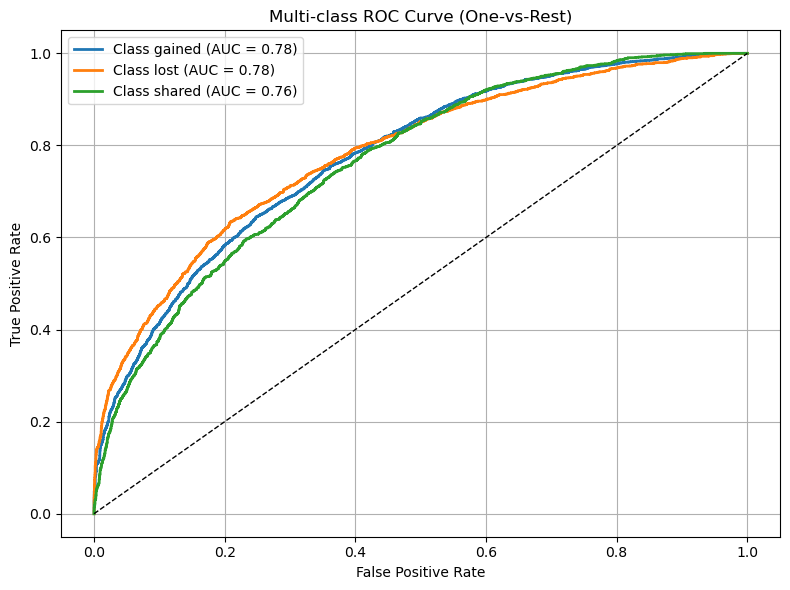

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # 3 classes
n_classes = y_test_bin.shape[1]

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
from xgboost import plot_importance
#plot_importance(model, importance_type='gain')

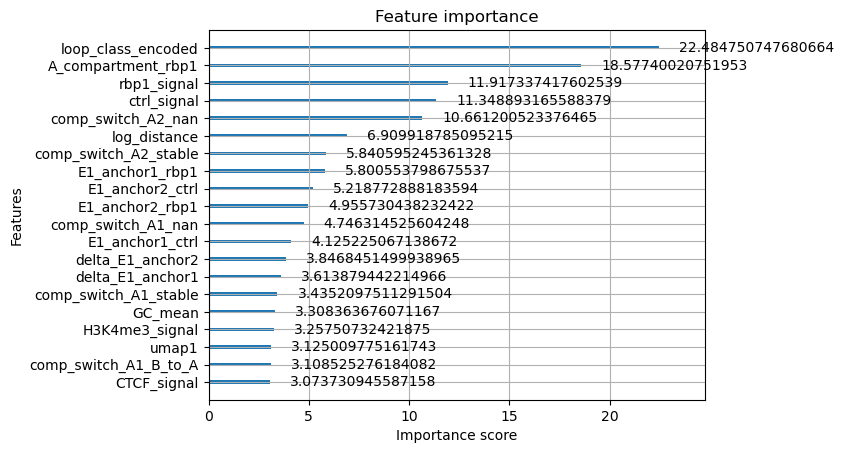

In [25]:
model.get_booster().feature_names = X.columns.tolist()
plot_importance(model, importance_type='gain', max_num_features=20)
plt.show()


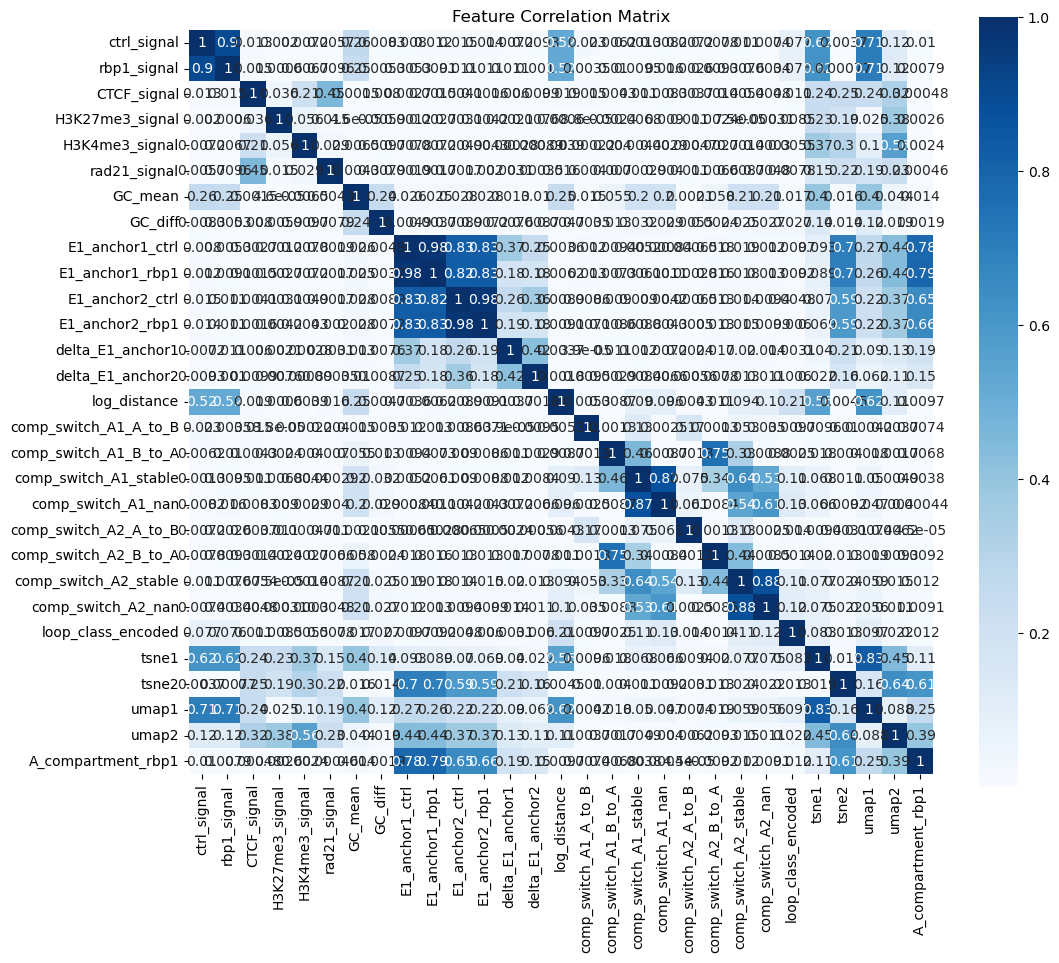

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='Blues', square=True)
plt.title("Feature Correlation Matrix")
plt.show()


In [27]:
threshold = 0.9
high_corr = [(i, j) for i in corr.columns for j in corr.columns if i != j and corr.loc[i, j] > threshold]
set([tuple(sorted(pair)) for pair in high_corr])


{('E1_anchor1_ctrl', 'E1_anchor1_rbp1'),
 ('E1_anchor2_ctrl', 'E1_anchor2_rbp1'),
 ('ctrl_signal', 'rbp1_signal')}

In [28]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Make sure X_test_df is a DataFrame with correct columns
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Get SHAP values per class
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)  # List of arrays

# Class labels (from LabelEncoder)
classes = le.classes_  # e.g., ['gained', 'lost', 'shared']

# Plot per-class SHAP summary
for i, class_name in enumerate(classes):
    print(f"SHAP summary for class: {class_name}")
    shap.summary_plot(shap_values[i], X_test_df, feature_names=X_test_df.columns.tolist(), max_display=20)


SHAP summary for class: gained


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

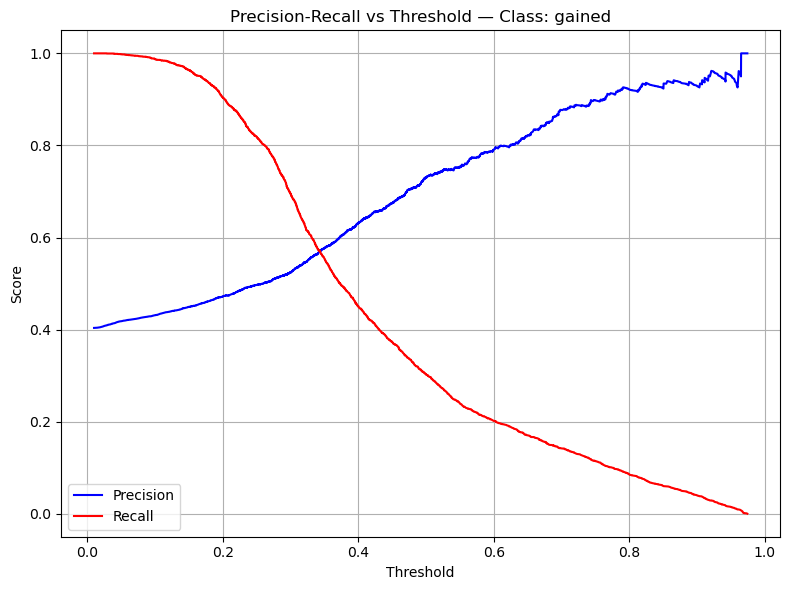

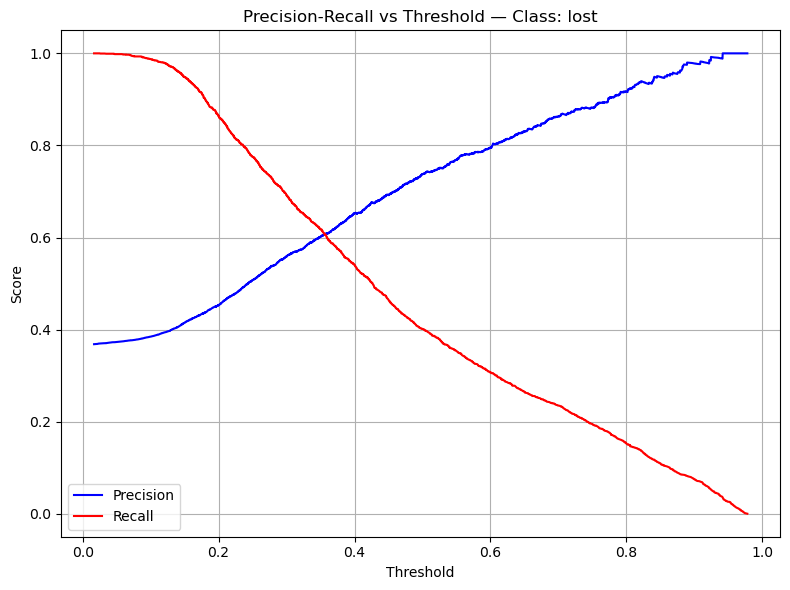

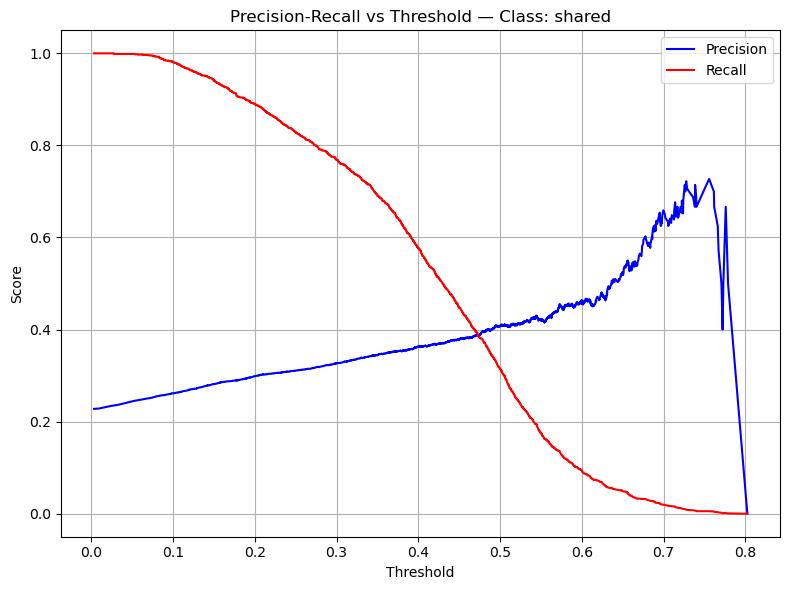

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Binarize y_test for 3-class setting
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # shape: (n_samples, 3)

# Plot precision-recall for each class
for i, class_name in enumerate(le.classes_):  # le is your LabelEncoder
    precision, recall, thresholds = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precision[:-1], label='Precision', color='b')
    plt.plot(thresholds, recall[:-1], label='Recall', color='r')
    plt.title(f'Precision-Recall vs Threshold — Class: {class_name}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Logistic regression model

In [ ]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

# Encode y from strings to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # e.g. gained=0, lost=1, shared=2


X_train_lgr, X_test_lgr, y_train_lgr, y_test_lgr = train_test_split(X, y_encoded, test_size=0.25, random_state=16)

In [ ]:
### code llm - for cleanup
# Handle data types and problematic values
# First, check for and handle infinite values
print("Checking for infinite values...")
if hasattr(X_train_lgr, 'replace'):  # if pandas DataFrame
    X_train_lgr = X_train_lgr.replace([np.inf, -np.inf], np.nan)
    X_test_lgr = X_test_lgr.replace([np.inf, -np.inf], np.nan)
else:  # if numpy array
    X_train_lgr[np.isinf(X_train_lgr)] = np.nan
    X_test_lgr[np.isinf(X_test_lgr)] = np.nan

# Handle missing values (including the inf values we just converted to NaN)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_lgr = imputer.fit_transform(X_train_lgr)
X_test_lgr = imputer.transform(X_test_lgr)

# Check for extremely large values that might cause overflow
print("Checking data ranges...")
print(f"X_train_lgr min: {np.min(X_train_lgr)}, max: {np.max(X_train_lgr)}")
print(f"X_test_lgr min: {np.min(X_test_lgr)}, max: {np.max(X_test_lgr)}")

# Convert to float32 after cleaning
X_train_lgr = X_train_lgr.astype(np.float32)
X_test_lgr = X_test_lgr.astype(np.float32)

# Convert target to integers if needed
y_train_lgr = y_train_lgr.astype(int)
y_test_lgr = y_test_lgr.astype(int)

Checking for infinite values...
Checking data ranges...
X_train_lgr min: -17.52109480589503, max: 16.791759928045582
X_test_lgr min: -16.517509535789017, max: 16.185442193508266


In [ ]:
from sklearn.linear_model import LogisticRegression

#instantiate
lgr_ins = LogisticRegression(random_state=20)

lgr_ins.fit(X_train_lgr, y_train_lgr)

y_prediction = lgr_ins.predict(X_test_lgr)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# evaluate

from sklearn import metrics
cnf = metrics.confusion_matrix(y_test_lgr, y_prediction)
cnf

array([[2516,  715,  123],
       [1136, 1612,  106],
       [1082,  599,  181]])

Text(0.5, 427.9555555555555, 'Predicted label')

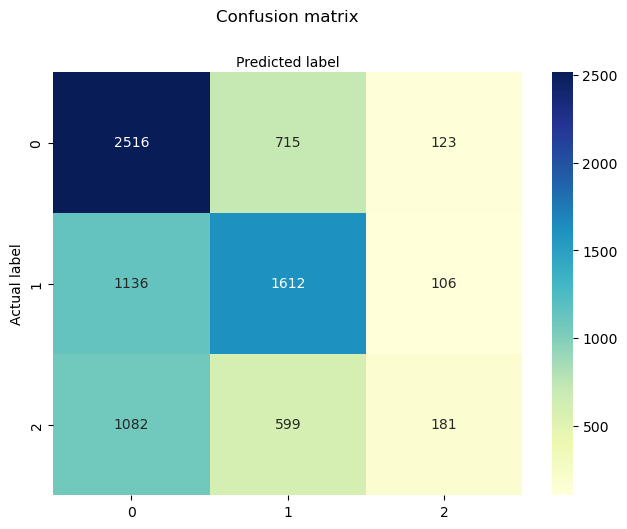

In [ ]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
from sklearn.metrics import classification_report
target_names = ['gained', 'lost', 'shared']
print(classification_report(y_test_lgr, y_prediction, target_names=target_names))

              precision    recall  f1-score   support

      gained       0.53      0.75      0.62      3354
        lost       0.55      0.56      0.56      2854
      shared       0.44      0.10      0.16      1862

    accuracy                           0.53      8070
   macro avg       0.51      0.47      0.45      8070
weighted avg       0.52      0.53      0.49      8070



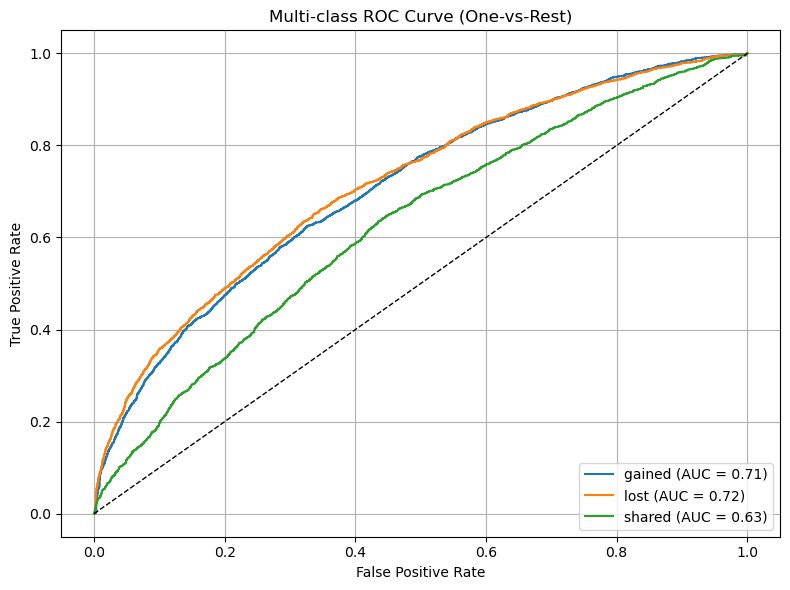

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Binarize labels: shape = (n_samples, 3)
y_test_bin = label_binarize(y_test_lgr, classes=[0, 1, 2])
class_names = le.classes_  # ['gained', 'lost', 'shared']

# Predict probabilities
y_pred_proba = lgr_ins.predict_proba(X_test_lgr)

# Plot all ROC curves
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


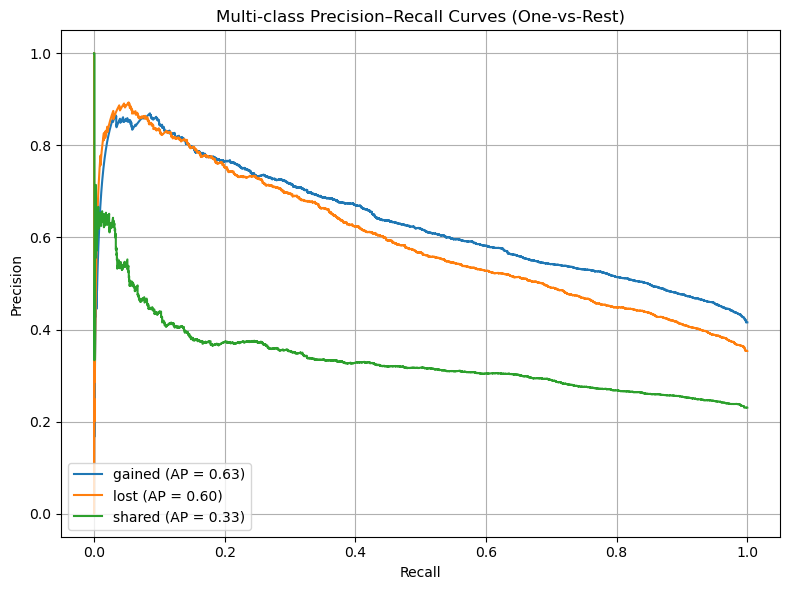

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Binarize y_test: shape = (n_samples, 3)
y_test_bin = label_binarize(y_test_lgr, classes=[0, 1, 2])
y_pred_proba_lgr = lgr_ins.predict_proba(X_test_lgr)

# Class names based on LabelEncoder
class_names = le.classes_  # e.g., ['gained', 'lost', 'shared']

# Plot PR curves for all classes
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_lgr[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba_lgr[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multi-class Precision–Recall Curves (One-vs-Rest)")
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# fine tuning the model

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.62      0.45      0.52      2607
           1       0.64      0.54      0.59      2379
           2       0.35      0.61      0.45      1470

    accuracy                           0.52      6456
   macro avg       0.54      0.54      0.52      6456
weighted avg       0.57      0.52      0.53      6456

